# Phase 2: Optimizers on a high-dimensional task

Phase 1 used 2-D surfaces so we could *see* the optimizer paths. But the real differences between optimizers show up in higher dimensions, where intuition from a picture runs out. Here we fit a genuinely hard target:

- **Inputs:** 10000 points on the unit sphere in **50 dimensions**.
- **Labels:** produced by a depth-4 **oblique decision tree (ODT)** - 16 leaves carved out by 15 oriented hyperplanes (see [`workshoplib/odt.py`](../workshoplib/odt.py)).
- **Model:** a small fully connected ReLU network trained with **cross-entropy** loss.

We train the same network with five optimizers - SGD, momentum, AdaGrad, Adam, and **MuON** - and compare their loss and accuracy curves. MuON (momentum orthogonalized by a Newton-Schulz iteration) finally has real weight *matrices* to act on, which is why we held it back from Phase 1.

In [1]:
from pathlib import Path
import os
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    os.chdir(ROOT.parent)
    ROOT = Path.cwd()

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("Working directory:", ROOT)

Working directory: /home/harish/researchcodes/optimization-workshop


In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import numpy as np
import torch
import matplotlib.pyplot as plt

from workshoplib.datagen import make_odt_classification_data
from workshoplib.model import make_mlp
from workshoplib.optimization import make_optimizer
from workshoplib.training import train_model
from workshoplib import viz

OPTIMIZERS = ["sgd", "momentum", "adagrad", "adam", "muon"]

## 1. Generate the ODT dataset

We draw 10000 labelled points and split them 80/20 into training and validation sets. Train and validation share the *same* decision tree, so validation accuracy measures how well the network generalizes the same target function to unseen points.

In [73]:
x_train, y_train, x_val, y_val, meta, tree = make_odt_classification_data(
    num_data=40000, dim=100, depth=4, seed=0, val_fraction=0.2
)

print("meta:", meta)
print("train:", tuple(x_train.shape), "val:", tuple(x_val.shape))
print("class balance (train):", round(float(y_train.float().mean()), 3))

meta: {'num_requested': 40000, 'num_kept': 40000, 'num_pruned': 0, 'dim': 100, 'depth': 4, 'num_internal_nodes': 15, 'num_leaf_nodes': 16, 'threshold': 0.0, 'seed': 0}
train: (32000, 100) val: (8000, 100)
class balance (train): 0.5


A 2-D PCA projection helps build intuition for *why* this is hard. The two classes are thoroughly mixed when squashed down to two dimensions - the ODT boundary lives in the full 50-D space and is not something a straight line (or a tiny network) can capture easily.

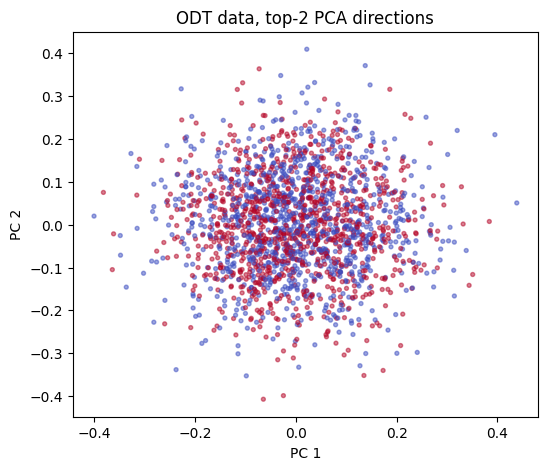

In [74]:
sample = x_train[:2000].numpy()
labels = y_train[:2000].numpy()
centered = sample - sample.mean(axis=0)
_, _, vt = np.linalg.svd(centered, full_matrices=False)
projection = centered @ vt[:2].T

plt.figure(figsize=(6, 5))
plt.scatter(projection[:, 0], projection[:, 1], c=labels, cmap="coolwarm", s=8, alpha=0.5)
plt.title("ODT data, top-2 PCA directions")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.show()

## 2. The model

A small fully connected ReLU classifier: `50 -> 16 -> 16 -> 2`. Two hidden layers of 16 units is deliberately modest - enough to make progress on the ODT target, small enough to run quickly and to make the optimizer differences matter.

In [75]:
print(make_mlp(input_dim=50, hidden_sizes=(24, 24, 24), num_classes=2))

Sequential(
  (0): Linear(in_features=50, out_features=24, bias=False)
  (1): ReLU()
  (2): Linear(in_features=24, out_features=24, bias=False)
  (3): ReLU()
  (4): Linear(in_features=24, out_features=24, bias=False)
  (5): ReLU()
  (6): Linear(in_features=24, out_features=2, bias=False)
)


## 3. Train with each optimizer

We train the identical network (same random initialization, via a fixed seed) with each optimizer, using mini-batch updates. Each optimizer uses a sensible default learning rate from [`workshoplib/optimization.py`](../workshoplib/optimization.py); you can override them later. We record train/validation loss and accuracy every epoch.

In [76]:
histories = {}
for name in OPTIMIZERS:
    torch.manual_seed(0)  # identical initialization for a fair comparison
    model = make_mlp(input_dim=x_train.shape[1], hidden_sizes=(24, 24, 24), num_classes=2)
    optimizer = make_optimizer(name, model.parameters())
    histories[name] = train_model(
        model, optimizer, x_train, y_train, x_val, y_val, epochs=100, batch_size=500, snapshot_every=10
    )
    print(f"{name:9s} done - final val accuracy {histories[name]['val_acc'][-1]:.3f}")

sgd       done - final val accuracy 0.864
momentum  done - final val accuracy 0.907
adagrad   done - final val accuracy 0.691
adam      done - final val accuracy 0.734
muon      done - final val accuracy 0.925


## 4. Compare the optimizers

Solid lines are training metrics, dashed lines of the same color are validation.

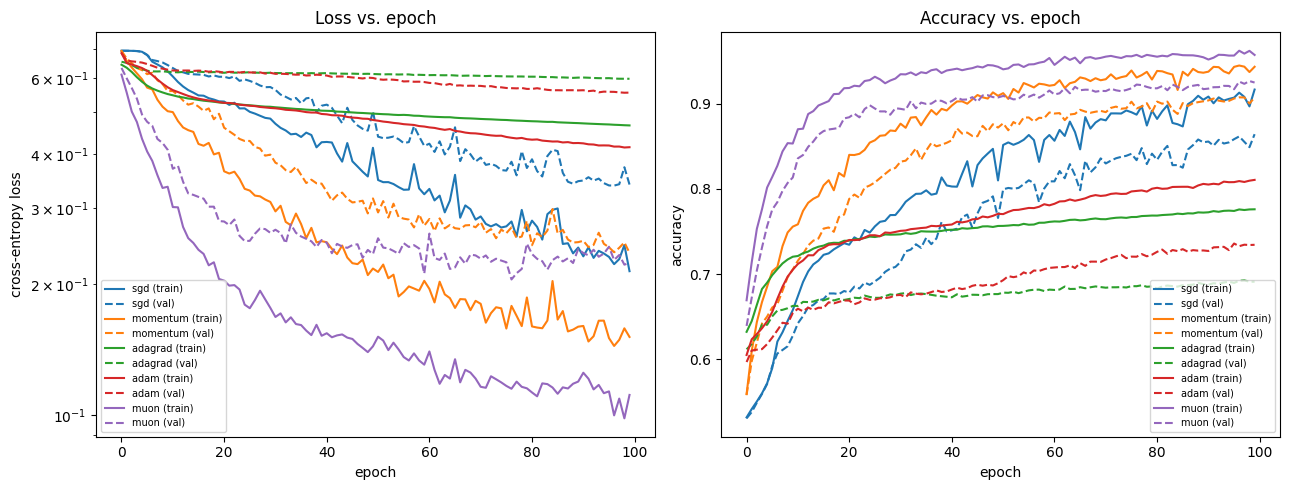

In [78]:
fig = viz.plot_training_curves(histories)
plt.show()

In [79]:
print(f"{'optimizer':10s} {'train_acc':>10s} {'val_acc':>10s}")
for name, h in histories.items():
    print(f"{name:10s} {h['train_acc'][-1]:10.3f} {h['val_acc'][-1]:10.3f}")

optimizer   train_acc    val_acc
sgd             0.917      0.864
momentum        0.943      0.907
adagrad         0.776      0.691
adam            0.811      0.734
muon            0.957      0.925


**What to notice:**

- Plain **SGD** drives the loss down the slowest and ends with the lowest accuracy - a single global step size struggles with the many differently-scaled directions of a 50-D problem.
- **Momentum** and the adaptive methods (**AdaGrad**, **Adam**) fit the training set noticeably faster.
- **MuON** typically reaches the best *validation* accuracy here: orthogonalizing each weight matrix's update spreads learning evenly across all directions of the layer rather than letting a few dominate, which on this task tends to generalize better.
- None of them get close to perfect accuracy - a depth-4 ODT in 50-D is genuinely hard for a small network, which is exactly the point: in high dimensions the choice of optimizer changes both how fast you learn and where you end up.

(Absolute numbers depend on the seed, learning rates, and training length - treat the *ordering and shape* of the curves as the lesson, not the exact values.)

## 5. Parameter snapshots

Because we passed `snapshot_every=10`, each history also carries a list of full parameter snapshots: the initial weights (epoch 0), every 10th epoch, and the final epoch. Each snapshot is a dict mapping parameter name to a detached copy of the tensor, so you can inspect the weights over training, measure how far they move, or reload the model at any captured point.

In [92]:
for name, h in histories.items():
    epochs_captured = [s["epoch"] for s in h["snapshots"]]
    print(f"{name:9s}: {len(epochs_captured)} snapshots at epochs {epochs_captured}")

# Each snapshot is a dict of parameter tensors:
example = histories["muon"]["snapshots"]
print("\nparameter tensors in one snapshot:")
for key, tensor in example[0]["params"].items():
    print(f"  {key:12s} {tuple(tensor.shape)}")

# Example use: how far did the weights travel from initialization?
print("\nL2 distance of final weights from initialization:")
for name, h in histories.items():
    init = h["snapshots"][0]["params"]
    final = h["snapshots"][-1]["params"]
    dist = sum(float((final[k] - init[k]).pow(2).sum()) for k in init) ** 0.5
    print(f"  {name:9s} {dist:.3f}")

# To reload any snapshot into a fresh model:
#   model = make_mlp(input_dim=50, hidden_sizes=(24, 24, 24), num_classes=2)
#   model.load_state_dict(histories["adam"]["snapshots"][2]["params"])  # epoch 20

sgd      : 11 snapshots at epochs [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
momentum : 11 snapshots at epochs [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
adagrad  : 11 snapshots at epochs [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
adam     : 11 snapshots at epochs [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
muon     : 11 snapshots at epochs [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

parameter tensors in one snapshot:
  0.weight     (24, 100)
  2.weight     (24, 24)
  4.weight     (24, 24)
  6.weight     (2, 24)

L2 distance of final weights from initialization:
  sgd       32.675
  momentum  83.252
  adagrad   10.873
  adam      12.101
  muon      154.341


In [95]:
algo = "sgd"
epoch_index =10
first_layer_weights = histories[algo]["snapshots"][epoch_index]["params"]["0.weight"].numpy()
tree_hyperplanes = tree.w_list
first_layer_weights_normalised = first_layer_weights / np.linalg.norm(first_layer_weights, axis=1, keepdims=True)
pairwise_norm_inner_prods = np.abs(first_layer_weights_normalised @ tree_hyperplanes.T)

In [96]:
print(pairwise_norm_inner_prods[:,0]>0.9)

[False  True False False False False False False  True False False False
 False False False False False False False False False False  True  True]


## 6. Why MuON wins: first-layer alignment to the ODT

The ODT labels every point using 15 oriented hyperplanes (depth 4 gives `2**4 - 1` internal nodes), and by construction their normals are orthogonal. A first-layer neuron is most useful when its weight vector lines up with one of these normals - then it acts as a detector for that hyperplane. So the natural question is: *how do the first-layer neurons distribute themselves across the 15 ODT normals during training, and does the optimizer change that?*

We measure, from the parameter snapshots, the alignment `|cos|` between each neuron and each ODT normal (helpers in [`workshoplib/analysis.py`](../workshoplib/analysis.py)). The root hyperplane (column 0) splits every point, so it produces the strongest gradient signal and tends to attract many neurons - a "resource hog" that can starve the other hyperplanes of detectors. MuON's orthogonalized updates discourage many neurons from chasing the same direction at once, which should spread neurons across the normals faster.

In [ ]:
from workshoplib import analysis

normals = tree.w_list          # (15, dim) ODT hyperplane normals; row 0 is the root
PAIR = ["momentum", "muon"]    # MuON vs its closest competitor
EARLY_EPOCH = 20               # an early snapshot where the optimizers differ most
FINAL_EPOCH = histories[PAIR[0]]["snapshots"][-1]["epoch"]

### Experiment 1 - Coverage: how fast are all 15 hyperplanes detected?

For each ODT hyperplane we take the best-aligned neuron; the hyperplane is "covered" once some neuron exceeds `|cos| > 0.9`. The left panel counts covered hyperplanes per epoch (the headline view of *speed*); the right panel shows the mean best-alignment as a smoother companion.

In [ ]:
fig = analysis.plot_coverage(histories, normals, threshold=0.9)
plt.show()

### Experiment 2 - Where does each neuron go?

Each row is a neuron (sorted by its best-matching hyperplane), each column an ODT hyperplane (root = column 0). Bright cells are detectors. We show an early epoch (where the speed difference lives) and the final epoch: early on, MuON already lights up (almost) every column, while momentum's bright cells are concentrated in a few columns with several dark, undetected hyperplanes.

In [ ]:
for ep in [EARLY_EPOCH, FINAL_EPOCH]:
    fig = analysis.plot_alignment_heatmaps(histories, normals, PAIR, epoch=ep)
    plt.show()

### Experiment 3 - Crowding: how many neurons land on each hyperplane?

Assign each confident neuron (`|cos| > 0.5`) to its best hyperplane and count them. Tall bars are over-allocation (often the root); missing bars are hyperplanes left undetected. Momentum tends to pile extra neurons onto a few hyperplanes and leave gaps; MuON spreads them more evenly.

In [ ]:
fig = analysis.plot_assignment_counts(histories, normals, PAIR, epoch=EARLY_EPOCH, threshold=0.5)
plt.show()

**What to notice:**

- **Coverage:** MuON reaches near-full hyperplane coverage many epochs before momentum - first-layer detectors for all 15 ODT hyperplanes appear sooner, which is what shows up downstream as faster accuracy.
- **Heatmaps:** early in training MuON already has bright cells spread across (almost) every column, while momentum's bright cells are concentrated in a few columns with several dark (undetected) hyperplanes.
- **Crowding:** momentum piles extra neurons onto a few hyperplanes (especially the root) and leaves others empty; MuON spreads neurons more evenly, so fewer hyperplanes go undetected.

This is the mechanism behind the speedup: by asking for near-orthogonal weight updates, MuON stops many neurons from redundantly chasing the dominant (root) direction. The layer therefore covers all the ODT hyperplanes - and fits the target - with less wasted, duplicated movement.

## Try it yourself

- Override a learning rate: `make_optimizer("sgd", model.parameters(), lr=0.5)`.
- Make the network bigger or deeper: `hidden_sizes=(20, 20, 20)` - does more capacity help validation accuracy, or just training accuracy?
- Make the task easier or harder: lower the ODT `depth` (3) or `dim` (e.g. 20) in `make_odt_classification_data`.
- Change the batch size and watch how the curves get noisier (small batches) or smoother (large batches).
- Train longer (`epochs=100`) and see whether the ordering of the optimizers holds up.